# 

## Running the Local LLaMA Model

Before running the notebook, make sure the local LLaMA server is running.

### 1. Clone or pull the repository and open the project folder

```powershell
cd path\to\subjective-assignment-3
```

### 2. Create the virtual environment

If you have not already created the virtual environment, run:

```powershell
python -m venv venv
```

### 3. Install `llama-cpp-python`

Make sure `llama-cpp-python` is installed inside the virtual environment.

First activate the environment:

```powershell
.\venv\Scripts\Activate.ps1
```

Then install:

```powershell
pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cpu
```

### 4. Download the LLaMA model

Download:

`Meta-Llama-3-8B-Instruct.Q4_K_M.gguf`

Create a folder called `models` inside the repository and place the model file there:

```text
subjective-assignment-3\
│
├── models\
│   └── Meta-Llama-3-8B-Instruct.Q4_K_M.gguf
├── data\
└── A3-notebook-group3.ipynb
```

### 5. Start the LLaMA server

Open PowerShell inside the repository and run:

```powershell
.\venv\Scripts\Activate.ps1

$modelPath = ".\models\Meta-Llama-3-8B-Instruct.Q4_K_M.gguf"

if (-Not (Test-Path $modelPath)) {
    Write-Host "ERROR: LLaMA model not found."
    Write-Host ""
    Write-Host "Place this file inside the models folder:"
    Write-Host "Meta-Llama-3-8B-Instruct.Q4_K_M.gguf"
    exit
}

Write-Host "Starting LLaMA 3 server..."
Write-Host "Keep this terminal open while running the notebook."
Write-Host ""

python -m llama_cpp.server `
    --host 127.0.0.1 `
    --port 8000 `
    --model $modelPath `
    --n_ctx 2048
```

When the server is ready, you should see something similar to:

```text
Uvicorn running on http://127.0.0.1:8000
```

**Keep this terminal open while running the notebook.**

The notebook connects to the model through:

```text
http://localhost:8000/v1
```

In [1]:
import sys
print(sys.executable)

C:\Users\97150\subjective-assignment-3\venv\Scripts\python.exe


In [1]:
import openai
from openai import OpenAI
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Point to the server
client = OpenAI(base_url="http://localhost:8000/v1", api_key="cltl")

In [3]:
# Sentences to classify
sentences = [
    "I hate you and I hope you fail.",
    "What a beautiful day to go for a walk!",
    "Your idea is stupid and nobody cares."
]

# Build a single prompt
prompt = "Classify each of the following sentences as 'hate' or 'non-hate':\n\n"
for i, s in enumerate(sentences, 1):
    prompt += f"{i}. {s}\n"

prompt += "\nReturn the results in the format:\n<number>. <label>\n"

# Make one request for all sentences
response = client.completions.create(
    model="local model",  # currently unused
    prompt=prompt,
    max_tokens=50,
    temperature=0,
    stop=["Classify", "\n\n"]
)

# Print the raw model output
print(response.choices[0].text.strip())

```
1. hate
2. non-hate
3. hate
```


In [4]:
test_df = pd.read_csv("data/olid-test.csv")

print(test_df.head())
print(test_df.columns)
print(test_df.shape)

      id                                               text  labels
0  15923  #WhoIsQ #WheresTheServer #DumpNike #DECLASFISA...       1
1  27014  #ConstitutionDay is revered by Conservatives, ...       0
2  30530  #FOXNews #NRA #MAGA #POTUS #TRUMP #2ndAmendmen...       0
3  13876  #Watching #Boomer getting the news that she is...       0
4  60133  #NoPasaran: Unity demo to oppose the far-right...       1
Index(['id', 'text', 'labels'], dtype='str')
(860, 3)


### Baseline Classifier

In [12]:
def classify_tweet(text):
    response = client.chat.completions.create(
        model="local model",
        messages=[
            {
                "role": "user",
                "content": f"""Classify the following tweet as OFF or NOT.

Tweet: {text}

Respond with exactly one label: OFF or NOT."""
            }
        ],
        temperature=0,
        max_tokens=10
    )

    raw = response.choices[0].message.content.strip().upper()

    match = re.search(r"\b(OFF|NOT)\b", raw)

    if match:
        label = match.group(1)
    else:
        label = "INVALID"

    return label, raw

In [6]:
prediction_labels = []
predictions = []
raw_outputs = []

for i, text in enumerate(test_df["text"]):

    label, raw = classify_tweet(text)

    prediction_labels.append(label)
    raw_outputs.append(raw)

    if label == "OFF":
        predictions.append(1)
    elif label == "NOT":
        predictions.append(0)
    else:
        predictions.append(None)

    print(f"{i + 1}/{len(test_df)}", end="\r")

test_df["prediction_label"] = prediction_labels
test_df["prediction"] = predictions
test_df["raw_output"] = raw_outputs

print("\nFinished.")

860/860
Finished.


In [7]:
print(test_df["prediction_label"].value_counts(dropna=False))

print(
    "\nInvalid predictions:",
    test_df["prediction"].isna().sum()
)

prediction_label
NOT        515
OFF        343
INVALID      2
Name: count, dtype: int64

Invalid predictions: 2


In [17]:
parse_fail_pct = (test_df["prediction"].isna().sum() / len(test_df)) * 100
print(f"Parse fail %: {parse_fail_pct:.2f}%")

Parse fail %: 0.23%


In [18]:
test_df.to_csv("baseline_predictions.csv",index=False)
print("Predictions saved to baseline_predictions.csv")

Predictions saved to baseline_predictions.csv


In [9]:
results = test_df.dropna(subset=["prediction"]).copy()
results["prediction"] = results["prediction"].astype(int)

print("Valid predictions:", len(results))
print("Invalid predictions:", len(test_df) - len(results))
print("Coverage:", len(results) / len(test_df))

print(
    classification_report(
        results["labels"],
        results["prediction"],
        labels=[0, 1],
        target_names=["NOT", "OFF"],
        digits=4
    )
)

macro_f1 = f1_score(
    results["labels"],
    results["prediction"],
    average="macro"
)

print("Macro F1:", macro_f1)

cm = confusion_matrix(
    results["labels"],
    results["prediction"],
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

Valid predictions: 858
Invalid predictions: 2
Coverage: 0.9976744186046511
              precision    recall  f1-score   support

         NOT     0.8563    0.7113    0.7771       620
         OFF     0.4781    0.6891    0.5645       238

    accuracy                         0.7051       858
   macro avg     0.6672    0.7002    0.6708       858
weighted avg     0.7514    0.7051    0.7181       858

Macro F1: 0.6708182004291552
Confusion Matrix:
[[441 179]
 [ 74 164]]


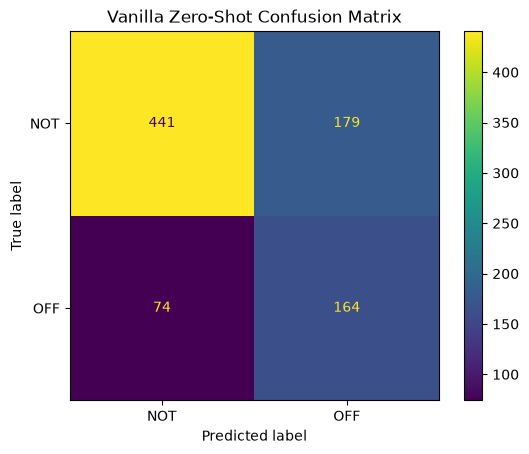

In [10]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NOT", "OFF"]
)

disp.plot()
plt.title("Vanilla Zero-Shot Confusion Matrix")
plt.show()

In [11]:
print("\n=== Vanilla Zero-Shot Baseline Results ===")
print(f"Valid predictions: {len(results)}")
print(f"Invalid predictions: {len(test_df) - len(results)}")
print(f"Coverage: {len(results) / len(test_df):.4f}")
print(f"Accuracy: 0.7051")
print(f"NOT F1-score: 0.7771")
print(f"OFF F1-score: 0.5645")
print(f"Macro F1-score: {macro_f1:.4f}")

print("\nConfusion Matrix:")
print(f"True NOT predicted NOT: {cm[0][0]}")
print(f"True NOT predicted OFF: {cm[0][1]}")
print(f"True OFF predicted NOT: {cm[1][0]}")
print(f"True OFF predicted OFF: {cm[1][1]}")


=== Vanilla Zero-Shot Baseline Results ===
Valid predictions: 858
Invalid predictions: 2
Coverage: 0.9977
Accuracy: 0.7051
NOT F1-score: 0.7771
OFF F1-score: 0.5645
Macro F1-score: 0.6708

Confusion Matrix:
True NOT predicted NOT: 441
True NOT predicted OFF: 179
True OFF predicted NOT: 74
True OFF predicted OFF: 164


## Experiment 4: Alternative labels

In this experiment we keep the baseline prompt (Experiment 1) **verbatim** and only replace the label words `OFF` / `NOT`. All decoding parameters are unchanged (`temperature=0`, `max_tokens=10`) and the same regex-based parser is used so any difference in performance can be attributed to the label words alone.

We test three label pairs:

| Run | OFF label | NOT label |
|---|---|---|
| **A** `toxic` | `TOXIC` | `NON-TOXIC` |
| **B** `respectful` | `TOXIC` | `RESPECTFUL` |
| **C** `inappropriate` | `INAPPROPRIATE` | `ACCEPTABLE` |

In [2]:
EXP4_LABEL_SETS = {
    "toxic":         {"pos": "TOXIC",         "neg": "NON-TOXIC"},
    "respectful":    {"pos": "TOXIC",         "neg": "RESPECTFUL"},
    "inappropriate": {"pos": "INAPPROPRIATE", "neg": "ACCEPTABLE"},
}

EXP4_TEMPLATE = """Classify the following tweet as {pos} or {neg}.

Tweet: {text}

Respond with exactly one label: {pos} or {neg}."""


def build_exp4_prompt(text, pos, neg):
    return EXP4_TEMPLATE.format(text=text, pos=pos, neg=neg)


def classify_tweet_exp4(text, pos, neg):
    response = client.chat.completions.create(
        model="local model",
        messages=[{"role": "user", "content": build_exp4_prompt(text, pos, neg)}],
        temperature=0,
        max_tokens=10,
    )

    raw = response.choices[0].message.content.strip().upper()

    match = re.search(rf"\b({re.escape(pos)}|{re.escape(neg)})\b", raw)

    label = match.group(1) if match else "INVALID"
    return label, raw


In [3]:
import os

os.makedirs("results", exist_ok=True)

exp4_results = {}

for name, labels in EXP4_LABEL_SETS.items():
    out_path = f"results/exp4_predictions_{name}.csv"
    df = pd.read_csv("data/olid-test.csv")

    if os.path.exists(out_path):
        print(f"[{name}] {out_path} already exists -> skipping classification, loading saved predictions")
        exp4_results[name] = pd.read_csv(out_path)
        continue

    print(f"[{name}] classifying {len(df)} tweets as {labels['pos']} / {labels['neg']}")
    prediction_labels, predictions, raw_outputs = [], [], []

    for i, text in enumerate(df["text"]):
        label, raw = classify_tweet_exp4(text, **labels)
        prediction_labels.append(label)
        raw_outputs.append(raw)
        if label == labels["pos"]:
            predictions.append(1)
        elif label == labels["neg"]:
            predictions.append(0)
        else:
            predictions.append(None)
        print(f"{i + 1}/{len(df)}", end="\r")

    df["prediction_label"] = prediction_labels
    df["prediction"] = predictions
    df["raw_output"] = raw_outputs
    exp4_results[name] = df

    df.to_csv(out_path, index=False)
    print(f"\n[{name}] saved to {out_path}")


[toxic] classifying 860 tweets as TOXIC / NON-TOXIC
860/860
[toxic] saved to exp4_predictions_toxic.csv
[respectful] classifying 860 tweets as TOXIC / RESPECTFUL
860/860
[respectful] saved to exp4_predictions_respectful.csv
[inappropriate] classifying 860 tweets as INAPPROPRIATE / ACCEPTABLE
860/860
[inappropriate] saved to exp4_predictions_inappropriate.csv


In [4]:
def evaluate_predictions(df, name):
    valid = df.dropna(subset=["prediction"]).copy()
    valid["prediction"] = valid["prediction"].astype(int)

    n_invalid = len(df) - len(valid)
    print(f"=== {name} ===")
    print(f"Valid predictions: {len(valid)}   Invalid: {n_invalid}   Coverage: {len(valid)/len(df):.4f}")
    print(df["prediction_label"].value_counts(dropna=False).to_string(), "\n")

    print(classification_report(valid["labels"], valid["prediction"],
                                labels=[0, 1], target_names=["NOT", "OFF"], digits=4))

    cm = confusion_matrix(valid["labels"], valid["prediction"], labels=[0, 1])
    print("Confusion matrix:\n", cm, "\n")

    report = classification_report(valid["labels"], valid["prediction"],
                                   labels=[0, 1], target_names=["NOT", "OFF"],
                                   output_dict=True, zero_division=0)
    return {
        "experiment": name,
        "n": len(df),
        "invalid": n_invalid,
        "coverage": len(valid) / len(df),
        "accuracy": report["accuracy"],
        "NOT_precision": report["NOT"]["precision"],
        "NOT_recall": report["NOT"]["recall"],
        "NOT_f1": report["NOT"]["f1-score"],
        "OFF_precision": report["OFF"]["precision"],
        "OFF_recall": report["OFF"]["recall"],
        "OFF_f1": report["OFF"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "cm": cm,
    }


exp4_metrics = []

# Baseline (Experiment 1) for comparison, read from the saved predictions
baseline_df = pd.read_csv("baseline_predictions.csv")
exp4_metrics.append(evaluate_predictions(baseline_df, "Exp 1: baseline (OFF / NOT)"))

for name, labels in EXP4_LABEL_SETS.items():
    exp4_metrics.append(
        evaluate_predictions(exp4_results[name], f"Exp 4 {name} ({labels['pos']} / {labels['neg']})")
    )


=== Exp 1: baseline (OFF / NOT) ===
Valid predictions: 858   Invalid: 2   Coverage: 0.9977
prediction_label
NOT        515
OFF        343
INVALID      2 

              precision    recall  f1-score   support

         NOT     0.8563    0.7113    0.7771       620
         OFF     0.4781    0.6891    0.5645       238

    accuracy                         0.7051       858
   macro avg     0.6672    0.7002    0.6708       858
weighted avg     0.7514    0.7051    0.7181       858

Confusion matrix:
 [[441 179]
 [ 74 164]] 

=== Exp 4 toxic (TOXIC / NON-TOXIC) ===
Valid predictions: 860   Invalid: 0   Coverage: 1.0000
prediction_label
NON-TOXIC    452
TOXIC        408 

              precision    recall  f1-score   support

         NOT     0.9027    0.6581    0.7612       620
         OFF     0.4804    0.8167    0.6049       240

    accuracy                         0.7023       860
   macro avg     0.6915    0.7374    0.6831       860
weighted avg     0.7848    0.7023    0.7176       860


,n,invalid,coverage,accuracy,NOT_precision,NOT_recall,NOT_f1,OFF_precision,OFF_recall,OFF_f1,macro_f1
experiment,,,,,,,,,,,
Exp 1: baseline (OFF / NOT),860,2,0.9977,0.7051,0.8563,0.7113,0.7771,0.4781,0.6891,0.5645,0.6708
Exp 4 toxic (TOXIC / NON-TOXIC),860,0,1.0000,0.7023,0.9027,0.6581,0.7612,0.4804,0.8167,0.6049,0.6831
Exp 4 respectful (TOXIC / RESPECTFUL),860,2,0.9977,0.6177,0.9619,0.4895,0.6488,0.4180,0.9498,0.5806,0.6147
Exp 4 inappropriate (INAPPROPRIATE / ACCEPTABLE),860,0,1.0000,0.6070,0.9273,0.4935,0.6442,0.4075,0.9000,0.5610,0.6026


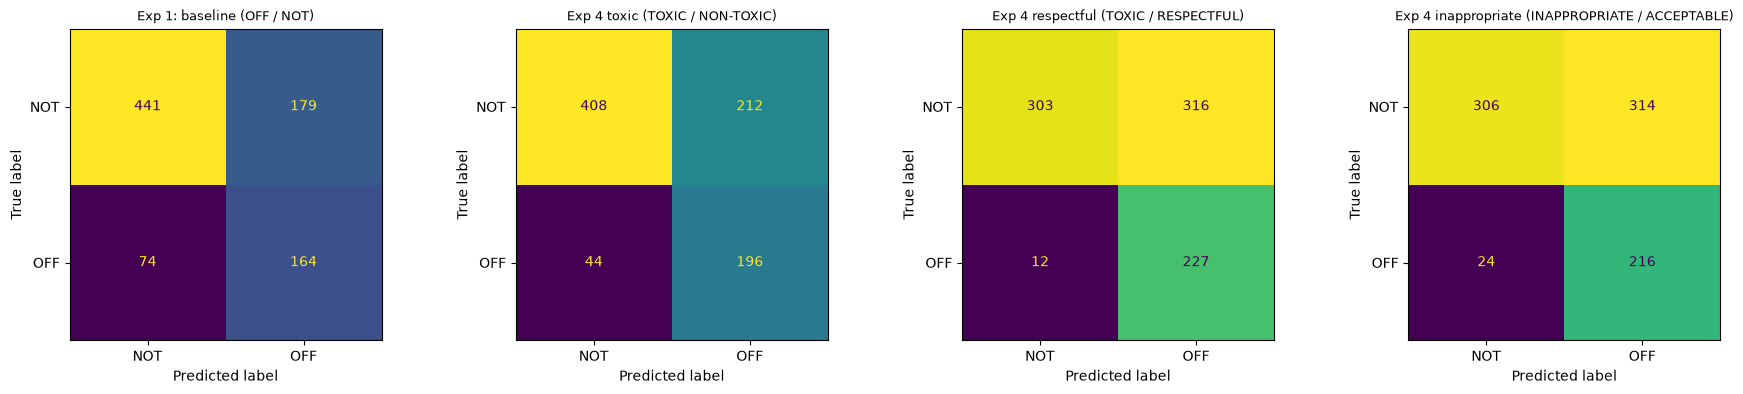

In [5]:
exp4_summary = pd.DataFrame(exp4_metrics).drop(columns="cm").set_index("experiment")
display(exp4_summary.round(4))

fig, axes = plt.subplots(1, len(exp4_metrics), figsize=(4.5 * len(exp4_metrics), 4))
for ax, m in zip(axes, exp4_metrics):
    ConfusionMatrixDisplay(confusion_matrix=m["cm"], display_labels=["NOT", "OFF"]).plot(ax=ax, colorbar=False)
    ax.set_title(m["experiment"], fontsize=9)
plt.tight_layout()
plt.show()


## Experiment 5: Few-shot prompts with random examples

In [3]:
FEWSHOT_K_VALUES = [1, 2, 4, 8]
FEWSHOT_SEEDS = [0, 1, 2]

FEWSHOT_TEMPLATE = """Classify the following tweet as OFF or NOT.

Here are some examples:
{examples}

Tweet: {text}

Respond with exactly one label: OFF or NOT."""


def build_fewshot_prompt(text, examples):
    """Build a few-shot prompt. `examples` is a list of (tweet_text, label) tuples in display order."""
    block = "\n".join(f'"{tweet}" -> {label}' for tweet, label in examples)
    return FEWSHOT_TEMPLATE.format(examples=block, text=text)


def classify_tweet_fewshot(text, examples):
    response = client.chat.completions.create(
        model="local model",
        messages=[{"role": "user", "content": build_fewshot_prompt(text, examples)}],
        temperature=0,
        max_tokens=10,
    )

    raw = response.choices[0].message.content.strip().upper()

    match = re.search(r"\b(OFF|NOT)\b", raw)

    label = match.group(1) if match else "INVALID"
    return label, raw


def sample_fewshot_examples(train_df, k, seed):
    """Balanced random sample: ceil(k/2) OFF + floor(k/2) NOT, interleaved (OFF first)."""
    n_off = (k + 1) // 2
    n_not = k // 2
    off = train_df[train_df["labels"] == 1].sample(n_off, random_state=seed)
    not_ = train_df[train_df["labels"] == 0].sample(n_not, random_state=seed)

    examples = []
    for i in range(max(n_off, n_not)):
        if i < len(off):
            examples.append((off.iloc[i]["text"], "OFF"))
        if i < len(not_):
            examples.append((not_.iloc[i]["text"], "NOT"))
    return examples


In [4]:
import os

os.makedirs("results", exist_ok=True)

# Fresh copies: test_df is re-read so the baseline prediction columns from
# Experiment 1 do not end up in the few-shot result files.
test_df_fs = pd.read_csv("data/olid-test.csv")
train_small_df = pd.read_csv("data/olid-train-small.csv")

# Exclude the 3 train tweets whose exact text also occurs in the test set,
# so that no few-shot example is identical to a test instance.
train_small_df = train_small_df[~train_small_df["text"].isin(test_df_fs["text"])].copy()

exp5_results = {}    # (k, seed) -> predictions DataFrame
exp5_examples = []   # record of which examples were sampled per (k, seed)

for k in FEWSHOT_K_VALUES:
    for seed in FEWSHOT_SEEDS:
        out_path = f"results/exp5_predictions_k{k}_s{seed}.csv"

        if os.path.exists(out_path):
            print(f"[k={k}, seed={seed}] {out_path} exists -> loading saved predictions")
            exp5_results[(k, seed)] = pd.read_csv(out_path)
            continue

        examples = sample_fewshot_examples(train_small_df, k, seed)
        for tweet, label in examples:
            exp5_examples.append({"k": k, "seed": seed, "example": tweet, "label": label})

        print(f"[k={k}, seed={seed}] classifying {len(test_df_fs)} tweets with {len(examples)} examples")
        prediction_labels, predictions, raw_outputs = [], [], []

        for i, text in enumerate(test_df_fs["text"]):
            label, raw = classify_tweet_fewshot(text, examples)
            prediction_labels.append(label)
            raw_outputs.append(raw)
            if label == "OFF":
                predictions.append(1)
            elif label == "NOT":
                predictions.append(0)
            else:
                predictions.append(None)
            print(f"{i + 1}/{len(test_df_fs)}", end="\r")

        df = test_df_fs.copy()
        df["prediction_label"] = prediction_labels
        df["prediction"] = predictions
        df["raw_output"] = raw_outputs
        exp5_results[(k, seed)] = df

        df.to_csv(out_path, index=False)
        print(f"\n[k={k}, seed={seed}] saved to {out_path}")

pd.DataFrame(exp5_examples).to_csv("results/exp5_sampled_examples.csv", index=False)
print("Sampled-examples log saved to results/exp5_sampled_examples.csv")


[k=1, seed=0] classifying 860 tweets with 1 examples
860/860
[k=1, seed=0] saved to results/exp5_predictions_k1_s0.csv
[k=1, seed=1] classifying 860 tweets with 1 examples
860/860
[k=1, seed=1] saved to results/exp5_predictions_k1_s1.csv
[k=1, seed=2] classifying 860 tweets with 1 examples
860/860
[k=1, seed=2] saved to results/exp5_predictions_k1_s2.csv
[k=2, seed=0] classifying 860 tweets with 2 examples
860/860
[k=2, seed=0] saved to results/exp5_predictions_k2_s0.csv
[k=2, seed=1] classifying 860 tweets with 2 examples
860/860
[k=2, seed=1] saved to results/exp5_predictions_k2_s1.csv
[k=2, seed=2] classifying 860 tweets with 2 examples
860/860
[k=2, seed=2] saved to results/exp5_predictions_k2_s2.csv
[k=4, seed=0] classifying 860 tweets with 4 examples
860/860
[k=4, seed=0] saved to results/exp5_predictions_k4_s0.csv
[k=4, seed=1] classifying 860 tweets with 4 examples
860/860
[k=4, seed=1] saved to results/exp5_predictions_k4_s1.csv
[k=4, seed=2] classifying 860 tweets with 4 exam

In [5]:
def compute_metrics(df):
    """Return per-class and macro metrics for a predictions DataFrame (no printing)."""
    valid = df.dropna(subset=["prediction"]).copy()
    valid["prediction"] = valid["prediction"].astype(int)

    report = classification_report(
        valid["labels"], valid["prediction"],
        labels=[0, 1], target_names=["NOT", "OFF"],
        output_dict=True, zero_division=0,
    )
    cm = confusion_matrix(valid["labels"], valid["prediction"], labels=[0, 1])

    return {
        "n": len(df),
        "invalid": len(df) - len(valid),
        "parse_fail_pct": 100 * (len(df) - len(valid)) / len(df),
        "accuracy": report["accuracy"],
        "NOT_precision": report["NOT"]["precision"],
        "NOT_recall": report["NOT"]["recall"],
        "NOT_f1": report["NOT"]["f1-score"],
        "OFF_precision": report["OFF"]["precision"],
        "OFF_recall": report["OFF"]["recall"],
        "OFF_f1": report["OFF"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "cm": cm,
    }


exp5_rows = []
for (k, seed), df in exp5_results.items():
    m = compute_metrics(df)
    m["k"] = k
    m["seed"] = seed
    exp5_rows.append(m)
    print(f"k={k} seed={seed}: macro-F1={m['macro_f1']:.4f}  parse fail={m['parse_fail_pct']:.2f}%  invalid={m['invalid']}")

exp5_by_seed = pd.DataFrame(exp5_rows).sort_values(["k", "seed"]).reset_index(drop=True)
exp5_by_seed.drop(columns=["cm"])


k=1 seed=0: macro-F1=0.6349  parse fail=0.23%  invalid=2
k=1 seed=1: macro-F1=0.6451  parse fail=0.47%  invalid=4
k=1 seed=2: macro-F1=0.6094  parse fail=0.47%  invalid=4
k=2 seed=0: macro-F1=0.7051  parse fail=0.12%  invalid=1
k=2 seed=1: macro-F1=0.6329  parse fail=0.58%  invalid=5
k=2 seed=2: macro-F1=0.6656  parse fail=0.58%  invalid=5
k=4 seed=0: macro-F1=0.6930  parse fail=0.35%  invalid=3
k=4 seed=1: macro-F1=0.5769  parse fail=0.70%  invalid=6
k=4 seed=2: macro-F1=0.6540  parse fail=0.47%  invalid=4
k=8 seed=0: macro-F1=0.6798  parse fail=0.35%  invalid=3
k=8 seed=1: macro-F1=0.6033  parse fail=0.70%  invalid=6
k=8 seed=2: macro-F1=0.6487  parse fail=0.47%  invalid=4


,n,invalid,parse_fail_pct,accuracy,NOT_precision,NOT_recall,NOT_f1,OFF_precision,OFF_recall,OFF_f1,macro_f1,k,seed
0,860,2,0.232558,0.756410,0.779292,0.924071,0.845528,0.620968,0.322176,0.424242,0.634885,1,0
1,860,4,0.465116,0.717290,0.800000,0.810373,0.805153,0.493506,0.476987,0.485106,0.645130,1,1
2,860,4,0.465116,0.734813,0.771468,0.899838,0.830723,0.537313,0.303797,0.388140,0.609432,1,2
3,860,1,0.116279,0.762515,0.835218,0.835218,0.835218,0.575000,0.575000,0.575000,0.705109,2,0
4,860,5,0.581395,0.650292,0.877069,0.600324,0.712776,0.428241,0.780591,0.553064,0.632920,2,1
5,860,5,0.581395,0.699415,0.856299,0.702746,0.771961,0.469741,0.690678,0.559177,0.665569,2,2
6,860,3,0.348837,0.725788,0.870656,0.728595,0.793316,0.504425,0.718487,0.592721,0.693018,4,0
7,860,6,0.697674,0.583138,0.887906,0.486268,0.628392,0.382524,0.838298,0.525333,0.576863,4,1
8,860,4,0.465116,0.686916,0.850299,0.688207,0.760714,0.456338,0.683544,0.547297,0.654006,4,2
9,860,3,0.348837,0.721120,0.846435,0.749191,0.794850,0.500000,0.648536,0.564663,0.679756,8,0


Baseline zero-shot macro-F1: 0.6708  parse fail: 0.23%


,accuracy,NOT_precision,NOT_recall,NOT_f1,OFF_precision,OFF_recall,OFF_f1,macro_f1,parse_fail_pct,macro_f1_std
k,,,,,,,,,,
1,0.7362,0.7836,0.8781,0.8271,0.5506,0.3677,0.4325,0.6298,0.3876,0.0184
2,0.7041,0.8562,0.7128,0.7733,0.4910,0.6821,0.5624,0.6679,0.4264,0.0361
4,0.6653,0.8696,0.6344,0.7275,0.4478,0.7468,0.5551,0.6413,0.5039,0.0591
8,0.6766,0.8474,0.6755,0.7483,0.4524,0.6800,0.5395,0.6439,0.5039,0.0385


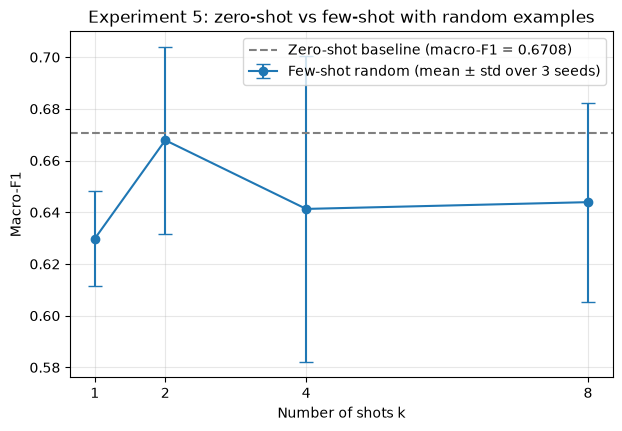

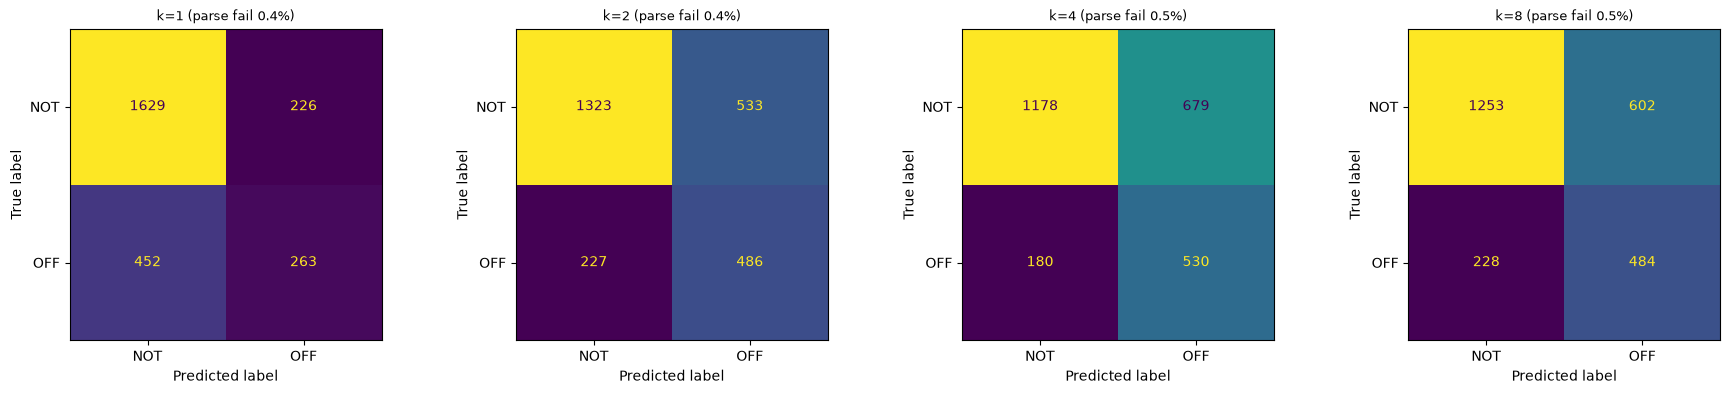

In [6]:
# Zero-shot baseline (Experiment 1) for comparison, read from the saved predictions
baseline_m = compute_metrics(pd.read_csv("baseline_predictions.csv"))
print(f"Baseline zero-shot macro-F1: {baseline_m['macro_f1']:.4f}  parse fail: {baseline_m['parse_fail_pct']:.2f}%")

# Mean over seeds (rows for the report table) + std for the error bars
metric_cols = ["accuracy", "NOT_precision", "NOT_recall", "NOT_f1",
               "OFF_precision", "OFF_recall", "OFF_f1", "macro_f1", "parse_fail_pct"]
exp5_report = exp5_by_seed.groupby("k")[metric_cols].mean()
exp5_report["macro_f1_std"] = exp5_by_seed.groupby("k")["macro_f1"].std()
display(exp5_report.round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
k_values = exp5_report.index.tolist()
ax.errorbar(k_values, exp5_report["macro_f1"], yerr=exp5_report["macro_f1_std"],
            marker="o", capsize=5, label="Few-shot random (mean ± std over 3 seeds)")
ax.axhline(baseline_m["macro_f1"], color="gray", linestyle="--",
           label=f"Zero-shot baseline (macro-F1 = {baseline_m['macro_f1']:.4f})")
ax.set_xlabel("Number of shots k")
ax.set_ylabel("Macro-F1")
ax.set_title("Experiment 5: zero-shot vs few-shot with random examples")
ax.set_xticks(k_values)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# Pooled confusion matrices per k (summed over the 3 seeds)
fig, axes = plt.subplots(1, len(k_values), figsize=(4.5 * len(k_values), 4))
for ax, k in zip(axes, k_values):
    cm = sum(m["cm"] for m in exp5_rows if m["k"] == k)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NOT", "OFF"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"k={k} (parse fail {exp5_report.loc[k, 'parse_fail_pct']:.1f}%)", fontsize=9)
plt.tight_layout()
plt.show()


## Experiment 6: Few-shot prompts with relevant examples

Examples were selected absed on the five criteria:

1. **Unambiguous (Non-)Offensiveness.** 
2. **OLID-like style.** 
3. **No refusal triggers.** The model refused to answer when the prompt contained maximally hateful tweets (e.g. racial slurs or incitement), inflating the parse-failure rate; such tweets are deliberately excluded from the relevant set.


| Pair | ID | Label | Tweet | Why it is relevant |
|---|---|---|---|---|
| 1 | 47242 | OFF | @USER F the DemocRATS.  SLIMY BASTARDS. | Unambiguous all-caps insult + profanity; prototype of political offense. |
| 1 | 65730 | NOT | @USER And yes your presidency was one of the absolute worst. Go back to that....no way. | Harsh political criticism with no slur or profanity (gold NOT) — the boundary case paired with 47242. |
| 2 | 93004 | OFF | @USER Europeans are morons for electing people like this | Group insult targeting people ("morons"). |
| 2 | 90956 | NOT | @USER @USER Clearly you are not a weather person.  Worst conditions are due for tomorrow. | Strongly negative wording ("worst") directed at the weather, not at people. |
| 3 | 41706 | OFF | @USER @USER Bitch shut up....cyberpunk was announced way back in 2012 and just now getting revealed #....get your facts straight | Direct @USER-directed insult ("bitch", "shut up") — typical OLID style. |
| 3 | 30815 | NOT | @USER Good morning. You are welcome. | Routine courteous @USER interaction. |
| 4 | 91855 | OFF | @USER @USER @USER Are you serious. Man you’re an idiot! He is the most hateful scum on earth. | Personal insult ("idiot") + derogatory noun ("scum"). |
| 4 | 64050 | NOT | @USER @USER @USER Hahahahaha!! really?: Stiglitz is Nobel prize 💡. You are a simple stockbroker 💩😂. | Mocking, condescending reply — negative but not offensive (gold NOT). |
| 5 | 73204 | OFF | @USER @USER @USER @USER @USER Because he is a scummy human being. | Short, purely derogatory statement. |
| 5 | 12171 | NOT | @USER @USER Happy Birthday Tyler! May God favor you with a day as AMAZING as you are! Be blessed today &amp; always!! 🎉🎉 | Celebratory, emphatic but clearly non-offensive. |
| 6 | 35022 | OFF | #GOP on personal responsibility...  He was drunk: boys will be boys  She was drunk: slut  #republicans #conservatives #kavanaugh | Gendered slur ("slut"). |
| 6 | 19087 | NOT | @USER @USER You are very beautifull | Compliment with @USER mentions. |
| 7 | 37753 | OFF | @USER @USER LMAOOO fucking love you see you hotties soon xox | Profanity with affectionate intent — gold OFF, teaches that profanity alone suffices. |
| 7 | 85171 | NOT | @USER @USER Love you Norm! | Affectionate with no profanity — the other half of the minimal pair. |
| 8 | 27802 | OFF | @USER @USER Further proving that #LiberalismCausesMentalRetardation and #Feminists are a cancer on the American Republic | Ableist slur + disease metaphor ("cancer"). |
| 8 | 98763 | NOT | @USER aw. *hugs* i’ve gotten flustered like that as well. it sucks. i also sometimes write myself a little script. you’re not alone. | Supportive reply containing mild negativity ("it sucks") — gold NOT. |


In [ ]:
RELEVANT_EXAMPLES = [
    (47242, 1, '@USER F the DemocRATS.  SLIMY BASTARDS.'),
    (65730, 0, '@USER And yes your presidency was one of the absolute worst. Go back to that....no way.'),
    (93004, 1, '@USER Europeans are morons for electing people like this'),
    (90956, 0, '@USER @USER Clearly you are not a weather person.  Worst conditions are due for tomorrow.'),
    (41706, 1, '@USER @USER Bitch shut up....cyberpunk was announced way back in 2012 and just now getting revealed #....get your facts straight'),
    (30815, 0, '@USER Good morning. You are welcome.'),
    (91855, 1, '@USER @USER @USER Are you serious. Man you’re an idiot! He is the most hateful scum on earth.'),
    (64050, 0, '@USER @USER @USER Hahahahaha!! really?: Stiglitz is Nobel prize 💡. You are a simple stockbroker 💩😂.'),
    (73204, 1, '@USER @USER @USER @USER @USER Because he is a scummy human being.'),
    (12171, 0, '@USER @USER Happy Birthday Tyler! May God favor you with a day as AMAZING as you are! Be blessed today &amp; always!! 🎉🎉'),
    (35022, 1, '#GOP on personal responsibility...  He was drunk: boys will be boys  She was drunk: slut  #republicans #conservatives #kavanaugh'),
    (19087, 0, '@USER @USER You are very beautifull'),
    (37753, 1, '@USER @USER LMAOOO fucking love you see you hotties soon xox'),
    (85171, 0, '@USER @USER Love you Norm!'),
    (27802, 1, '@USER @USER Further proving that #LiberalismCausesMentalRetardation and #Feminists are a cancer on the American Republic'),
    (98763, 0, '@USER aw. *hugs* i’ve gotten flustered like that as well. it sucks. i also sometimes write myself a little script. you’re not alone.'),
]


def relevant_examples_for_k(k):
    return [(text, "OFF" if label == 1 else "NOT") for _, label, text in RELEVANT_EXAMPLES[:k]]


exp6_results = {}

for k in FEWSHOT_K_VALUES:
    out_path = f"results/exp6_predictions_k{k}.csv"

    if os.path.exists(out_path):
        print(f"[k={k}] {out_path} exists -> loading saved predictions")
        exp6_results[k] = pd.read_csv(out_path)
        continue

    examples = relevant_examples_for_k(k)
    print(f"[k={k}] classifying {len(test_df_fs)} tweets with {len(examples)} relevant examples")
    prediction_labels, predictions, raw_outputs = [], [], []

    for i, text in enumerate(test_df_fs["text"]):
        label, raw = classify_tweet_fewshot(text, examples)
        prediction_labels.append(label)
        raw_outputs.append(raw)
        if label == "OFF":
            predictions.append(1)
        elif label == "NOT":
            predictions.append(0)
        else:
            predictions.append(None)
        print(f"{i + 1}/{len(test_df_fs)}", end="\r")

    df = test_df_fs.copy()
    df["prediction_label"] = prediction_labels
    df["prediction"] = predictions
    df["raw_output"] = raw_outputs
    exp6_results[k] = df

    df.to_csv(out_path, index=False)
    print(f"\n[k={k}] saved to {out_path}")


[k=1] classifying 860 tweets with 1 relevant examples
860/860
[k=1] saved to results/exp6_predictions_k1.csv
[k=2] classifying 860 tweets with 2 relevant examples
860/860
[k=2] saved to results/exp6_predictions_k2.csv
[k=4] classifying 860 tweets with 4 relevant examples
860/860
[k=4] saved to results/exp6_predictions_k4.csv
[k=8] classifying 860 tweets with 8 relevant examples
860/860
[k=8] saved to results/exp6_predictions_k8.csv


k=1: macro-F1=0.6773  parse fail=0.35%  invalid=3
k=2: macro-F1=0.6732  parse fail=0.23%  invalid=2
k=4: macro-F1=0.7019  parse fail=0.93%  invalid=8
k=8: macro-F1=0.6989  parse fail=0.93%  invalid=8


,k,random_macro_f1,random_std,random_parse_fail_pct,relevant_macro_f1,relevant_parse_fail_pct,delta
0,1,0.6298,0.0184,0.3876,0.6773,0.3488,0.0474
1,2,0.6679,0.0361,0.4264,0.6732,0.2326,0.0053
2,4,0.6413,0.0591,0.5039,0.7019,0.9302,0.0606
3,8,0.6439,0.0385,0.5039,0.6989,0.9302,0.0550


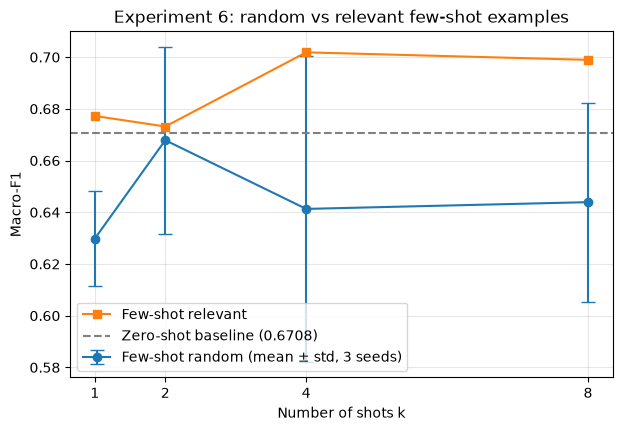

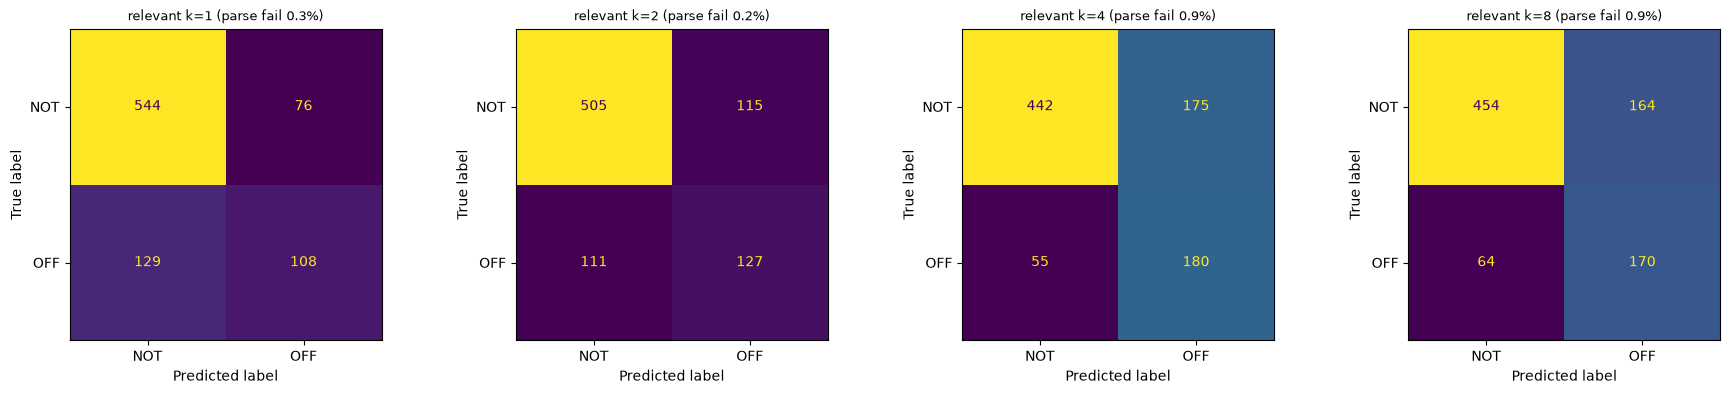

In [ ]:
exp6_rows = []
for k, df in exp6_results.items():
    m = compute_metrics(df)
    m["k"] = k
    exp6_rows.append(m)
    print(f"k={k}: macro-F1={m['macro_f1']:.4f}  parse fail={m['parse_fail_pct']:.2f}%  invalid={m['invalid']}")

exp6_df = pd.DataFrame(exp6_rows).sort_values("k").reset_index(drop=True)

comparison = pd.DataFrame({
    "k": exp6_df["k"],
    "random_macro_f1": exp5_report.loc[exp6_df["k"], "macro_f1"].values,
    "random_std": exp5_report.loc[exp6_df["k"], "macro_f1_std"].values,
    "random_parse_fail_pct": exp5_report.loc[exp6_df["k"], "parse_fail_pct"].values,
    "relevant_macro_f1": exp6_df["macro_f1"],
    "relevant_parse_fail_pct": exp6_df["parse_fail_pct"],
})
comparison["delta"] = comparison["relevant_macro_f1"] - comparison["random_macro_f1"]
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(comparison["k"], comparison["random_macro_f1"], yerr=comparison["random_std"],
            marker="o", capsize=5, label="Few-shot random (mean ± std, 3 seeds)")
ax.plot(comparison["k"], comparison["relevant_macro_f1"], marker="s", label="Few-shot relevant")
ax.axhline(baseline_m["macro_f1"], color="gray", linestyle="--",
           label=f"Zero-shot baseline ({baseline_m['macro_f1']:.4f})")
ax.set_xlabel("Number of shots k")
ax.set_ylabel("Macro-F1")
ax.set_title("Experiment 6: random vs relevant few-shot examples")
ax.set_xticks(comparison["k"])
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, len(FEWSHOT_K_VALUES), figsize=(4.5 * len(FEWSHOT_K_VALUES), 4))
for ax, k in zip(axes, FEWSHOT_K_VALUES):
    m = exp6_df[exp6_df["k"] == k].iloc[0]
    ConfusionMatrixDisplay(confusion_matrix=m["cm"], display_labels=["NOT", "OFF"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"relevant k={k} (parse fail {m['parse_fail_pct']:.1f}%)", fontsize=9)
plt.tight_layout()
plt.show()
